# NEO Hazardous Classification with a Feature-Reuploading QNN

This notebook trains a PennyLane + PyTorch quantum neural network to predict whether a near-Earth object is hazardous.

The model is intentionally quantum-only: in the current configuration (`USE_PCA = False`), the five engineered tabular features are standardized, scaled as rotation angles, and passed directly into a 5-qubit quantum circuit. If `USE_PCA` is switched on, the same preprocessing cell reduces the standardized features to 4 PCA components before angle scaling. The only trainable model parameters are the ansatz angles `theta`.

`FEATURE_REUPLOADS` controls how many times the notebook applies the `feature map -> ansatz` block. Use an integer to train one QNN, or a list such as `[1, 2, 3]` to compare depths.

## 1. Imports and Dataset Loading

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# Preload CUDA 13 NVRTC builtins so PennyLane/Torch CUDA kernels can JIT-compile.
# torch's libnvrtc.so.13 calls dlopen("libnvrtc-builtins.so.13.0") without searching
# torch/lib, so we resolve and load it explicitly here.
import ctypes, os
for _candidate in (
    os.path.join(os.path.dirname(torch.__file__), "lib", "libnvrtc-builtins.so.13.0"),
    "/home/pennati/phd/quantum/quantumPyCPU311/lib/python3.11/site-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0",
):
    if os.path.exists(_candidate):
        ctypes.CDLL(_candidate, mode=ctypes.RTLD_GLOBAL)
        break

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

cuda_available = torch.cuda.is_available()
torch_device = torch.device("cuda")

if cuda_available:
    torch.cuda.manual_seed_all(SEED)

print(f"PennyLane version: {qml.__version__}")
print(f"Torch version:     {torch.__version__}")
print(f"Torch CUDA:        {torch.version.cuda}")
print(f"CUDA available:    {cuda_available}")
print(f"QNN Torch device:  {torch_device}")

csv_path = Path("/home/pennati/phd/quantum_machine_learning/project/data/neo.csv")
dataset = pd.read_csv(csv_path)

print(f"Loaded dataset from: {csv_path.resolve()}")
print(f"Dataset shape: {dataset.shape}")
dataset.head()

PennyLane version: 0.44.1
Torch version:     2.9.1+cu130
Torch CUDA:        13.0
CUDA available:    True
QNN Torch device:  cuda
Loaded dataset from: /home/pennati/phd/quantum_machine_learning/project/data/neo.csv
Dataset shape: (90836, 10)


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.1983,2.6794,"13,569.2492","54,839,744.0828",Earth,False,16.7300,False
1,2277475,277475 (2005 WK4),0.2658,0.5943,"73,588.7267","61,438,126.5240",Earth,False,20.0000,True
2,2512244,512244 (2015 YE18),0.7220,1.6145,"114,258.6921","49,798,724.9405",Earth,False,17.8300,False
3,3596030,(2012 BV13),0.0965,0.2158,"24,764.3031","25,434,972.7208",Earth,False,22.2000,False
4,3667127,(2014 GE35),0.2550,0.5702,"42,737.7338","46,275,567.0013",Earth,False,20.0900,True


## 2. Cleaning and Target Inspection

Missing values per column:
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64
Duplicate rows: 0


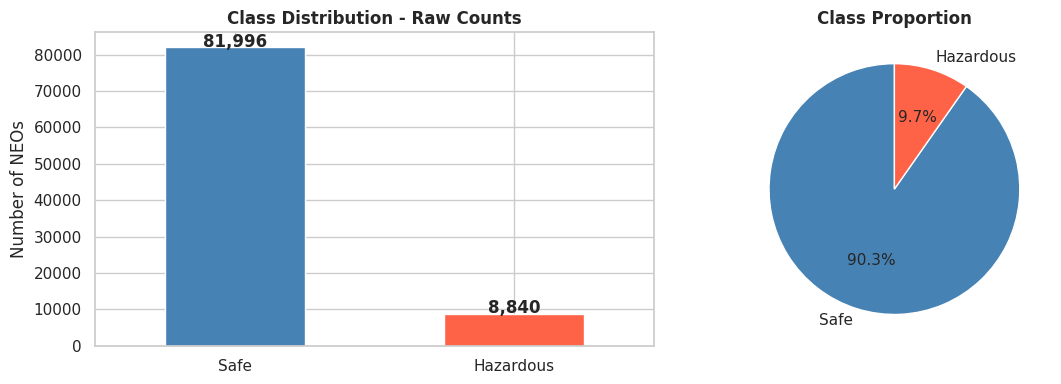

Hazardous: 8,840 (9.7%)
Safe:      81,996 (90.3%)
Imbalance ratio (safe : hazardous): 9.3 : 1


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,1.1983,2.6794,"13,569.2492","54,839,744.0828",16.7300,False
1,0.2658,0.5943,"73,588.7267","61,438,126.5240",20.0000,True
2,0.7220,1.6145,"114,258.6921","49,798,724.9405",17.8300,False
3,0.0965,0.2158,"24,764.3031","25,434,972.7208",22.2000,False
4,0.2550,0.5702,"42,737.7338","46,275,567.0013",20.0900,True


In [3]:
print("Missing values per column:")
print(dataset.isnull().sum())
print(f"Duplicate rows: {dataset.duplicated().sum():,}")

df_clean = dataset.drop(columns=["id", "name", "orbiting_body", "sentry_object"]).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

counts = df_clean["hazardous"].value_counts().sort_index()
counts.index = ["Safe", "Hazardous"]
counts.plot(kind="bar", ax=ax1, color=["steelblue", "tomato"])
ax1.set_title("Class Distribution - Raw Counts", fontweight="bold")
ax1.set_ylabel("Number of NEOs")
ax1.tick_params(axis="x", rotation=0)
for i, value in enumerate(counts):
    ax1.text(i, value + 200, f"{value:,}", ha="center", fontweight="bold")

proportions = df_clean["hazardous"].value_counts(normalize=True).sort_index()
proportions.index = ["Safe", "Hazardous"]
ax2.pie(
    proportions,
    labels=proportions.index,
    colors=["steelblue", "tomato"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11},
)
ax2.set_title("Class Proportion", fontweight="bold")

plt.tight_layout()
plt.show()

hazardous_count = int(df_clean["hazardous"].sum())
safe_count = len(df_clean) - hazardous_count

print(f"Hazardous: {hazardous_count:,} ({hazardous_count / len(df_clean) * 100:.1f}%)")
print(f"Safe:      {safe_count:,} ({safe_count / len(df_clean) * 100:.1f}%)")
print(f"Imbalance ratio (safe : hazardous): {safe_count / hazardous_count:.1f} : 1")

df_clean.head()

## 3. Exploratory Analysis

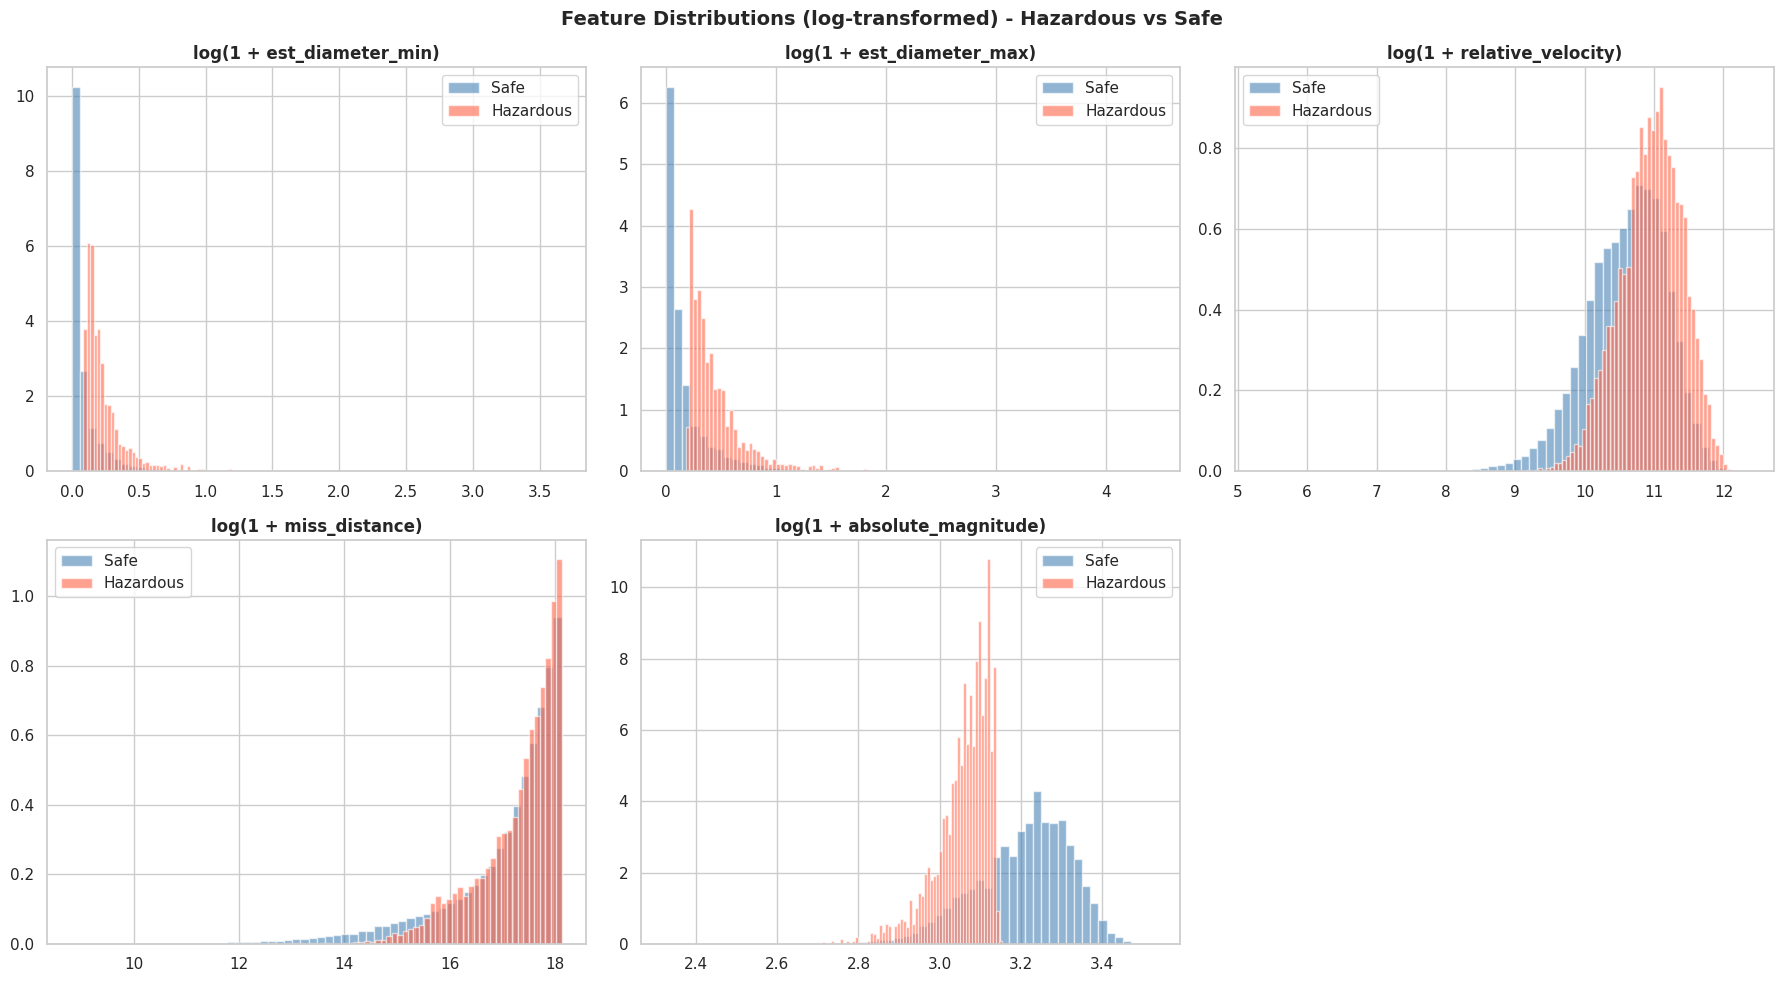

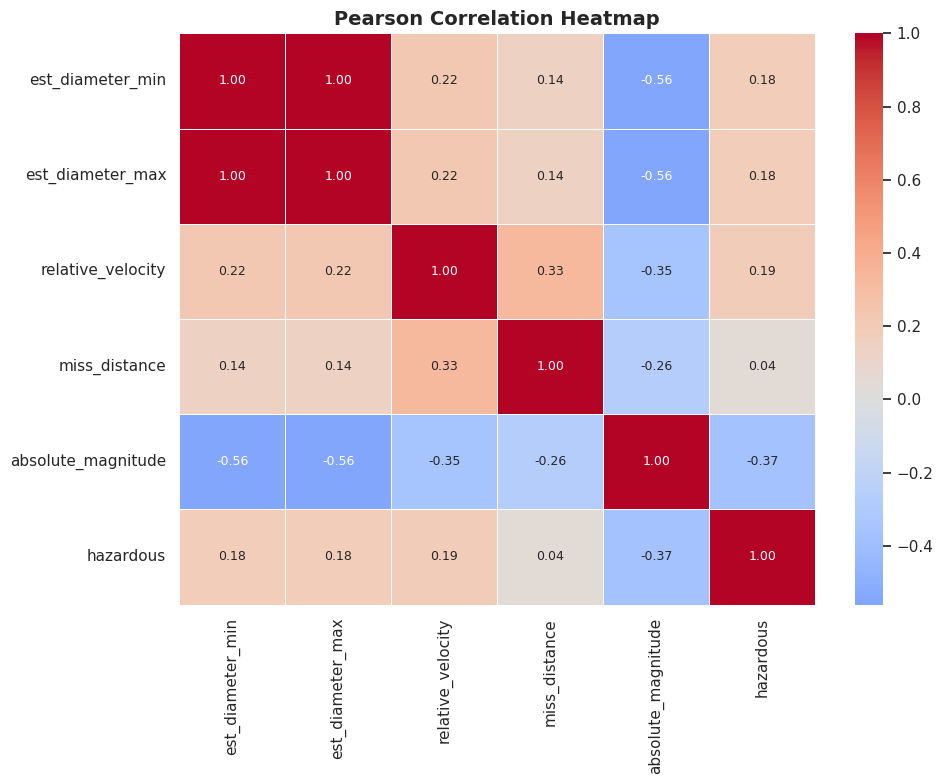

absolute_magnitude   -0.3653
miss_distance         0.0423
est_diameter_min      0.1834
est_diameter_max      0.1834
relative_velocity     0.1912
hazardous             1.0000
Name: hazardous, dtype: float64

In [4]:
features = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude",
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    safe_vals = df_clean.loc[~df_clean["hazardous"], col]
    haz_vals = df_clean.loc[df_clean["hazardous"], col]
    axes[i].hist(np.log1p(safe_vals), bins=60, alpha=0.6, label="Safe", color="steelblue", density=True)
    axes[i].hist(np.log1p(haz_vals), bins=60, alpha=0.6, label="Hazardous", color="tomato", density=True)
    axes[i].set_title(f"log(1 + {col})", fontweight="bold")
    axes[i].legend()

for ax in axes[len(features):]:
    ax.set_visible(False)

plt.suptitle("Feature Distributions (log-transformed) - Hazardous vs Safe", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

df_corr = df_clean.copy()
df_corr["hazardous"] = df_corr["hazardous"].astype(int)
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
)
plt.title("Pearson Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr["hazardous"].sort_values()

## 4. Feature Engineering

X shape: (90836, 5)
y counts:
hazardous
0    81996
1     8840
Name: count, dtype: int64


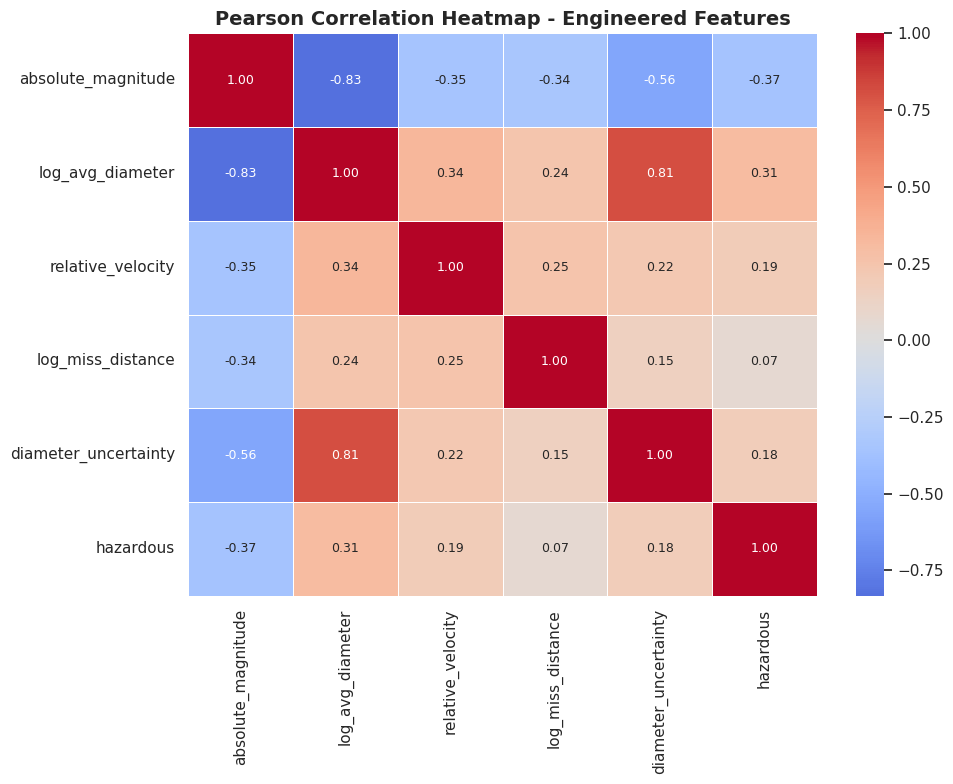

absolute_magnitude     -0.3653
log_miss_distance       0.0651
diameter_uncertainty    0.1834
relative_velocity       0.1912
log_avg_diameter        0.3107
hazardous               1.0000
Name: hazardous, dtype: float64

In [5]:
df_features = df_clean.copy()

df_features["avg_diameter"] = (df_features["est_diameter_min"] + df_features["est_diameter_max"]) / 2
df_features["diameter_uncertainty"] = df_features["est_diameter_max"] - df_features["est_diameter_min"]
df_features["log_avg_diameter"] = np.log1p(df_features["avg_diameter"])
df_features["log_miss_distance"] = np.log1p(df_features["miss_distance"])

FEATURES = [
    "absolute_magnitude",
    "log_avg_diameter",
    "relative_velocity",
    "log_miss_distance",
    "diameter_uncertainty",
]
TARGET = "hazardous"

X = df_features[FEATURES].copy()
y = df_features[TARGET].astype(int)

print(f"X shape: {X.shape}")
print("y counts:")
print(y.value_counts())

feature_summary = X.describe().T[["mean", "std", "min", "max"]]
feature_summary

df_corr = df_features[FEATURES + [TARGET]].copy()
df_corr["hazardous"] = df_corr["hazardous"].astype(int)
corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9},
)
plt.title("Pearson Correlation Heatmap - Engineered Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

corr["hazardous"].sort_values()

## 5. Train, Validation, and Test Split

In [6]:
# Split the natural dataset first. Any class balancing is applied only to the
# QNN training subset later; validation and test remain untouched and realistic.
X_np = X.to_numpy(dtype=np.float32)
y_np = y.to_numpy(dtype=np.int64)

# 70 / 15 / 15 stratified split using sklearn.
X_tr_np, X_tmp_np, y_tr_np, y_tmp_np = train_test_split(
    X_np, y_np, test_size=0.30, random_state=SEED, stratify=y_np
)
X_val_np, X_te_np, y_val_np, y_te_np = train_test_split(
    X_tmp_np, y_tmp_np, test_size=0.50, random_state=SEED, stratify=y_tmp_np
)

print(f"Train size:      {len(X_tr_np):,}")
print(f"Validation size: {len(X_val_np):,}")
print(f"Test size:       {len(X_te_np):,}")
print(f"Train hazardous:      {int(y_tr_np.sum()):,} / {len(y_tr_np):,} ({y_tr_np.mean() * 100:.1f}%)")
print(f"Validation hazardous: {int(y_val_np.sum()):,} / {len(y_val_np):,} ({y_val_np.mean() * 100:.1f}%)")
print(f"Test hazardous:       {int(y_te_np.sum()):,} / {len(y_te_np):,} ({y_te_np.mean() * 100:.1f}%)")

# Keep the class weight tied to the natural training distribution regardless
# of the QNN runtime subset sampling mode.
train_pos_weight_value = float((y_tr_np == 0).sum() / max((y_tr_np == 1).sum(), 1))
print(f"Positive-class loss weight from natural train split: {train_pos_weight_value:.2f}")

Train size:      63,585
Validation size: 13,625
Test size:       13,626
Train hazardous:      6,188 / 63,585 (9.7%)
Validation hazardous: 1,326 / 13,625 (9.7%)
Test hazardous:       1,326 / 13,626 (9.7%)
Positive-class loss weight from natural train split: 9.28


## 6. Torch Preprocessing for the QNN

Set `USE_PCA = True` to standardize, project to 4 PCA components, and run the QNN with **4 qubits** (one rotation per component). Set `USE_PCA = False` to skip PCA entirely: every standardized engineered feature is passed in directly and the QNN uses **`n_qubits = len(FEATURES)`** (one qubit per feature). In both cases the values are min-max scaled into `[-pi/2, pi/2]` using training-set extrema.

In [7]:
# Toggle PCA preprocessing for the QNN.
#   USE_PCA=True  -> standardize -> PCA(4) -> min-max into [-pi/2, pi/2], n_qubits=4.
#   USE_PCA=False -> standardize ->          min-max into [-pi/2, pi/2], n_qubits=len(FEATURES).
USE_PCA = False

# 1. Standardize using training-set statistics only.
scaler_std = StandardScaler().fit(X_tr_np)
X_tr_std = scaler_std.transform(X_tr_np)
X_val_std = scaler_std.transform(X_val_np)
X_te_std = scaler_std.transform(X_te_np)

# 2. Optional PCA dimensionality reduction.
if USE_PCA:
    n_qubits = 4
    pca = PCA(n_components=n_qubits, random_state=SEED).fit(X_tr_std)
    X_tr_red = pca.transform(X_tr_std)
    X_val_red = pca.transform(X_val_std)
    X_te_red = pca.transform(X_te_std)
    pca_summary = pd.DataFrame(
        {
            "component": [f"PC{i}" for i in range(1, n_qubits + 1)],
            "explained_variance": pca.explained_variance_ratio_,
            "cumulative_variance": np.cumsum(pca.explained_variance_ratio_),
        }
    )
else:
    n_qubits = X_tr_std.shape[1]
    X_tr_red, X_val_red, X_te_red = X_tr_std, X_val_std, X_te_std
    pca_summary = pd.DataFrame({"note": [f"PCA disabled; using all {n_qubits} standardized features"]})

# 3. Min-max scale each component into [-pi/2, pi/2] for angle encoding.
angle_scaler = MinMaxScaler(feature_range=(-np.pi / 2, np.pi / 2)).fit(X_tr_red)
X_tr_ang = angle_scaler.transform(X_tr_red).astype(np.float32)
X_val_ang = angle_scaler.transform(X_val_red).astype(np.float32)
X_te_ang = angle_scaler.transform(X_te_red).astype(np.float32)

# 4. Move to torch tensors on the QNN device.
X_tr_quantum = torch.from_numpy(X_tr_ang).to(torch_device)
X_val_quantum = torch.from_numpy(X_val_ang).to(torch_device)
X_te_quantum = torch.from_numpy(X_te_ang).to(torch_device)

y_tr_tensor = torch.from_numpy(y_tr_np.astype(np.float32)).reshape(-1, 1).to(torch_device)
y_val_tensor = torch.from_numpy(y_val_np.astype(np.float32)).reshape(-1, 1).to(torch_device)
y_te_tensor = torch.from_numpy(y_te_np.astype(np.float32)).reshape(-1, 1).to(torch_device)

print(f"USE_PCA = {USE_PCA}")
print(f"Original engineered features: {X_tr_np.shape[1]}")
print(f"Quantum input features (n_qubits): {X_tr_quantum.shape[1]}")
if USE_PCA:
    print(f"Total PCA variance retained: {pca.explained_variance_ratio_.sum():.3f}")
pca_summary

USE_PCA = False
Original engineered features: 5
Quantum input features (n_qubits): 5


,note
0,PCA disabled; using all 5 standardized features


## 7. Quantum Runtime Subsets

Quantum simulation dominates runtime even with PennyLane batch broadcasting, so the QNN uses configurable subsets. In the current configuration (`BALANCE_QNN_TRAIN_SUBSET = False`), train, validation, and test subsets are sampled from their natural stratified splits; optional training-only class balancing is available via the toggle.

In [8]:
# Requested maximum sizes for the QNN runtime subsets.
# If a requested size exceeds a split, stratified_sample returns all available
# examples for the over-requested class, so the actual subset can be smaller.
QNN_TRAIN_SAMPLES = 50000
QNN_VAL_SAMPLES = 12096
QNN_TEST_SAMPLES = 12096
BALANCE_QNN_TRAIN_SUBSET = False


def take_class_indices(y_flat, label, n_take, generator, device):
    indices = torch.where(y_flat == label)[0]
    indices = indices[torch.randperm(indices.numel(), generator=generator, device=device)]
    return indices[:n_take]


def apply_sample_indices(X_tensor, y_tensor, indices, generator):
    indices = indices[torch.randperm(indices.numel(), generator=generator, device=X_tensor.device)]
    return X_tensor[indices], y_tensor[indices]


def stratified_sample(X_tensor, y_tensor, n_samples, seed):
    generator = torch.Generator(device=X_tensor.device)
    generator.manual_seed(seed)
    y_flat = y_tensor.flatten().long()
    n_pos = round(n_samples * y_flat.float().mean().item())
    n_neg = n_samples - n_pos

    indices = torch.cat([
        take_class_indices(y_flat, 0, n_neg, generator, X_tensor.device),
        take_class_indices(y_flat, 1, n_pos, generator, X_tensor.device),
    ])
    return apply_sample_indices(X_tensor, y_tensor, indices, generator)


def class_balanced_sample(X_tensor, y_tensor, n_samples, seed):
    generator = torch.Generator(device=X_tensor.device)
    generator.manual_seed(seed)
    y_flat = y_tensor.flatten().long()
    n_per_class = min(
        n_samples // 2,
        int((y_flat == 0).sum().item()),
        int((y_flat == 1).sum().item()),
    )
    if n_per_class == 0:
        raise ValueError("Both classes are required for a balanced QNN training subset.")

    indices = torch.cat([
        take_class_indices(y_flat, 0, n_per_class, generator, X_tensor.device),
        take_class_indices(y_flat, 1, n_per_class, generator, X_tensor.device),
    ])
    return apply_sample_indices(X_tensor, y_tensor, indices, generator)


if BALANCE_QNN_TRAIN_SUBSET:
    X_tr_qnn, y_tr_qnn = class_balanced_sample(X_tr_quantum, y_tr_tensor, QNN_TRAIN_SAMPLES, SEED)
else:
    X_tr_qnn, y_tr_qnn = stratified_sample(X_tr_quantum, y_tr_tensor, QNN_TRAIN_SAMPLES, SEED)
X_val_qnn, y_val_qnn = stratified_sample(X_val_quantum, y_val_tensor, QNN_VAL_SAMPLES, SEED + 1)
X_te_qnn, y_te_qnn = stratified_sample(X_te_quantum, y_te_tensor, QNN_TEST_SAMPLES, SEED + 2)

print(f"BALANCE_QNN_TRAIN_SUBSET = {BALANCE_QNN_TRAIN_SUBSET}")
pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "samples": [len(y_tr_qnn), len(y_val_qnn), len(y_te_qnn)],
        "hazardous": [int(y_tr_qnn.sum().item()), int(y_val_qnn.sum().item()), int(y_te_qnn.sum().item())],
        "hazardous_%": [
            y_tr_qnn.mean().item() * 100,
            y_val_qnn.mean().item() * 100,
            y_te_qnn.mean().item() * 100,
        ],
    }
)

BALANCE_QNN_TRAIN_SUBSET = False


,split,samples,hazardous,hazardous_%
0,train,50000,4866,9.7320
1,validation,12096,1177,9.7305
2,test,12096,1177,9.7305


## 8. Feature Map

Built-in IQP-style feature map (`qml.IQPEmbedding`, Havlíček et al. 2019): Hadamards + per-qubit `RZ(a_i)` followed by pairwise `MultiRZ(a_i * a_j)` ZZ entanglers. With `pattern=None`, PennyLane applies the entanglers to all wire pairs; `n_repeats` controls how many times that embedding is repeated. Encoder-side entanglement comes from the ZZ couplings; the variational ansatz adds further CNOT-based entanglement.

In [9]:
readout_wire = 0
qml_device_name = "default.qubit"
qnode_diff_method = "backprop"

dev = qml.device(qml_device_name, wires=n_qubits, shots=None)

# IQP-style feature map (Havlicek et al. 2019): Hadamards + RZ(a_i) on each qubit
# followed by MultiRZ(a_i * a_j) ZZ entanglers on all wire pairs by default.
# Provided by PennyLane as qml.IQPEmbedding.
IQP_N_REPEATS = 1

def feature_map_qnn(feature_angles):
    # feature_angles may be shape (n_qubits,) or (batch, n_qubits) for broadcasting.
    qml.IQPEmbedding(features=feature_angles, wires=range(n_qubits), n_repeats=IQP_N_REPEATS)


print(f"PennyLane device: {qml_device_name}, diff_method={qnode_diff_method}, interface=torch")
print(f"Feature map: qml.IQPEmbedding(n_repeats={IQP_N_REPEATS})")

PennyLane device: default.qubit, diff_method=backprop, interface=torch
Feature map: qml.IQPEmbedding(n_repeats=1)


## 9. Feature Reuploading Block

`FEATURE_REUPLOADS` controls the number of repeated `feature map -> ansatz` blocks.

In [10]:
# Compare the requested feature-reuploading depths.
FEATURE_REUPLOADS = [2, 3, 4]
ANSATZ_LAYERS = 1

reupload_depths = [FEATURE_REUPLOADS] if isinstance(FEATURE_REUPLOADS, int) else list(FEATURE_REUPLOADS)


def theta_shape(reuploads):
    # For each reupload block, qml.StronglyEntanglingLayers expects weights of
    # shape (n_layers, n_qubits, 3): three rotation angles (Rot = RZ RY RZ) per
    # qubit per layer, plus a built-in entangling CNOT pattern.
    return (reuploads, ANSATZ_LAYERS, n_qubits, 3)


def variational_ansatz(theta_block):
    # theta_block has shape (ANSATZ_LAYERS, n_qubits, 3).
    qml.StronglyEntanglingLayers(weights=theta_block, wires=range(n_qubits))


def repeated_qnn(feature_angles, theta):
    for theta_block in theta:
        feature_map_qnn(feature_angles)
        variational_ansatz(theta_block)


for depth in reupload_depths:
    print(f"N={depth}: theta_shape={theta_shape(depth)}, quantum_parameters={np.prod(theta_shape(depth))}")

N=2: theta_shape=(2, 1, 5, 3), quantum_parameters=30
N=3: theta_shape=(3, 1, 5, 3), quantum_parameters=45
N=4: theta_shape=(4, 1, 5, 3), quantum_parameters=60


## 10. Quantum Classifier

The PyTorch module stores only the trainable quantum parameters. The QNode uses `default.qubit` with `interface="torch"` and `diff_method="backprop"`, so the circuit participates directly in Torch autograd. The Pauli-Z expectation is used directly as the binary logit.

In [11]:
@qml.qnode(dev, interface="torch", diff_method=qnode_diff_method)
def qnn_circuit(feature_angles, theta):
    repeated_qnn(feature_angles, theta)
    return qml.expval(qml.PauliZ(readout_wire))


class QuantumHazardClassifier(nn.Module):
    def __init__(self, reuploads, init_scale=0.05):
        super().__init__()
        self.reuploads = reuploads
        self.theta = nn.Parameter(torch.randn(theta_shape(reuploads), dtype=torch.float32, device=torch_device) * init_scale)

    def forward(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)

        x = x.to(device=torch_device, dtype=torch.float32)
        # default.qubit supports parameter broadcasting: pass the whole batch in one call.
        z = qnn_circuit(x, self.theta)
        return z.reshape(-1, 1).float()


probe_model = QuantumHazardClassifier(reuploads=reupload_depths[0]).to(torch_device)
x_probe = X_tr_qnn[:4]

with torch.no_grad():
    probe_logits = probe_model(x_probe)

print(probe_model)
print(f"Probe batch shape: {tuple(x_probe.shape)}")
print(f"Probe logits shape: {tuple(probe_logits.shape)}")
print(f"Probe probabilities: {torch.sigmoid(probe_logits).detach().cpu().numpy().round(3).ravel()}")

QuantumHazardClassifier()
Probe batch shape: (4, 5)
Probe logits shape: (4, 1)
Probe probabilities: [0.507 0.54  0.609 0.632]


## 11. Training Helpers

The loss uses a positive-class weight computed from the full natural training split, so `BCEWithLogitsLoss` stays weighted independently of the QNN runtime subset sampling mode. Threshold tuning is done on validation data only.

In [12]:
batch_size = 256
eval_batch_size = 256
eps = 1e-12


def make_loader(X_tensor, y_tensor, shuffle=False):
    data = TensorDataset(X_tensor.to(torch_device), y_tensor.to(torch_device))
    return DataLoader(data, batch_size=batch_size, shuffle=shuffle)


def predict_logits(model, X_tensor, batch_size=eval_batch_size):
    model.eval()
    logits = []

    with torch.no_grad():
        for start in range(0, len(X_tensor), batch_size):
            xb = X_tensor[start : start + batch_size].to(torch_device)
            logits.append(model(xb).detach())

    return torch.cat(logits, dim=0)


def weighted_bce_loss(logits, y_tensor):
    return F.binary_cross_entropy_with_logits(logits, y_tensor.to(logits.device), pos_weight=pos_weight).item()


def predict_proba(model, X_tensor, batch_size=eval_batch_size):
    return torch.sigmoid(predict_logits(model, X_tensor, batch_size=batch_size)).flatten()


def ranking_metrics(y_true, y_score):
    y_true = y_true.flatten().float()
    y_score = y_score.flatten()
    order = torch.argsort(y_score, descending=True)
    sorted_true = y_true[order]
    tp = torch.cumsum(sorted_true, dim=0)
    fp = torch.cumsum(1 - sorted_true, dim=0)
    positives = y_true.sum().clamp_min(1.0)
    negatives = (1 - y_true).sum().clamp_min(1.0)
    precision = tp / (tp + fp + eps)
    recall = tp / positives
    recall_delta = recall - torch.cat([torch.zeros(1, device=y_true.device), recall[:-1]])
    avg_precision = torch.sum(recall_delta * precision)
    tpr = torch.cat([torch.zeros(1, device=y_true.device), tp / positives, torch.ones(1, device=y_true.device)])
    fpr = torch.cat([torch.zeros(1, device=y_true.device), fp / negatives, torch.ones(1, device=y_true.device)])
    return torch.trapz(tpr, fpr), avg_precision


def classification_metrics(y_true, y_pred, y_proba):
    y_true = y_true.flatten().float()
    y_pred = y_pred.flatten().float()
    tp = ((y_true == 1) & (y_pred == 1)).sum().float()
    tn = ((y_true == 0) & (y_pred == 0)).sum().float()
    fp = ((y_true == 0) & (y_pred == 1)).sum().float()
    fn = ((y_true == 1) & (y_pred == 0)).sum().float()
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    roc_auc, avg_precision = ranking_metrics(y_true, y_proba)
    return {
        "accuracy": ((tp + tn) / (tp + tn + fp + fn + eps)).item(),
        "precision": precision.item(),
        "recall": recall.item(),
        "f1": f1.item(),
        "roc_auc": roc_auc.item(),
        "avg_precision": avg_precision.item(),
    }


def threshold_metrics_curve(y_true, y_proba):
    y_true = y_true.flatten().bool()
    y_proba = y_proba.flatten()
    thresholds = torch.unique(y_proba.detach()).sort().values
    pred = y_proba.unsqueeze(0) >= thresholds.unsqueeze(1)
    truth = y_true.unsqueeze(0)
    tp = (pred & truth).sum(dim=1).float()
    fp = (pred & ~truth).sum(dim=1).float()
    fn = (~pred & truth).sum(dim=1).float()
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return thresholds, precision, recall, f1


def evaluate(model, X_tensor, y_tensor, threshold):
    y_proba = predict_proba(model, X_tensor)
    y_pred = (y_proba >= threshold).long()
    return {
        "metrics": classification_metrics(y_tensor, y_pred, y_proba),
        "y_pred": y_pred,
        "y_proba": y_proba,
    }


def tune_threshold(model, X_tensor, y_tensor):
    y_proba = predict_proba(model, X_tensor)
    thresholds, precision, recall, f1 = threshold_metrics_curve(y_tensor, y_proba)
    best_idx = torch.argmax(f1)
    curve = pd.DataFrame(
        {
            "threshold": thresholds.detach().cpu().numpy(),
            "precision": precision.detach().cpu().numpy(),
            "recall": recall.detach().cpu().numpy(),
            "f1": f1.detach().cpu().numpy(),
        }
    )
    return thresholds[best_idx].item(), curve


def confusion_matrix_torch(y_true, y_pred):
    y_true = y_true.flatten().long()
    y_pred = y_pred.flatten().long()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    tp = ((y_true == 1) & (y_pred == 1)).sum()
    return torch.stack([torch.stack([tn, fp]), torch.stack([fn, tp])])


def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix_torch(y_true, y_pred).detach().cpu().numpy()
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        cbar=False,
        xticklabels=["Safe", "Hazardous"],
        yticklabels=["Safe", "Hazardous"],
        ax=ax,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()


train_loader = make_loader(X_tr_qnn, y_tr_qnn, shuffle=True)

pos_weight = torch.tensor([train_pos_weight_value], dtype=torch.float32, device=torch_device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"Batch size: {batch_size}")
print(f"Eval batch size: {eval_batch_size}")
print(f"Positive-class loss weight (natural train neg/pos): {pos_weight.item():.2f}")

Batch size: 256
Eval batch size: 256
Positive-class loss weight (natural train neg/pos): 9.28


## 12. Train QNNs

Each requested reupload depth is trained once, then evaluated with a validation-tuned threshold.

In [13]:
# Print the QNode circuit for each requested reupload depth before training.
import torch as _torch

_dummy_x = X_tr_qnn[:1].detach()  # shape (1, n_qubits)

for _depth in reupload_depths:
    _theta_dummy = _torch.zeros(theta_shape(_depth))
    _drawer = qml.draw(qnn_circuit, max_length=140, decimals=2)
    print(f"\n=== Circuit for FEATURE_REUPLOADS = {_depth}, ANSATZ_LAYERS = {ANSATZ_LAYERS} ===")
    print(_drawer(_dummy_x[0], _theta_dummy))
    _specs = qml.specs(qnn_circuit)(_dummy_x[0], _theta_dummy)
    print(f"gate counts: {_specs['resources'].gate_types}")
    print(f"depth: {_specs['resources'].depth}, total gates: {_specs['resources'].num_gates}")


=== Circuit for FEATURE_REUPLOADS = 2, ANSATZ_LAYERS = 1 ===
0: ─╭IQPEmbedding(M0)─╭StronglyEntanglingLayers(M1)─╭IQPEmbedding(M0)─╭StronglyEntanglingLayers(M1)─┤  <Z>
1: ─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
2: ─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
3: ─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─├IQPEmbedding(M0)─├StronglyEntanglingLayers(M1)─┤     
4: ─╰IQPEmbedding(M0)─╰StronglyEntanglingLayers(M1)─╰IQPEmbedding(M0)─╰StronglyEntanglingLayers(M1)─┤     

M0 = 
tensor([ 0.8237, -1.5613, -0.9865,  0.7641, -1.5701], device='cuda:0')
M1 = 
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])
gate counts: {'IQPEmbedding': 2, 'StronglyEntanglingLayers': 2}
depth: 4, total gates: 4

=== Circuit for FEATURE_REUPLOADS = 3, ANSATZ_LAYERS = 1 ===
0: ─╭IQPEmbedding(M0)─╭StronglyEntanglingLayers(M1)

In [14]:
max_epochs = 25
learning_rate = 0.03


def train_qnn(reuploads):
    torch.manual_seed(SEED + 100 * reuploads)

    model = QuantumHazardClassifier(reuploads).to(torch_device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []

    print()
    print(f"Training QNN with N={reuploads} feature reupload(s)")
    print(f"Trainable quantum parameters: {model.theta.numel()}")

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_loss = 0.0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * len(xb)

        train_loss /= len(train_loader.dataset)
        row = {
            "reuploads": reuploads,
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": float("nan"),
            "val_avg_precision": float("nan"),
            "val_roc_auc": float("nan"),
        }


        val_logits = predict_logits(model, X_val_qnn)
        val_loss = weighted_bce_loss(val_logits, y_val_qnn)
        val_proba = torch.sigmoid(val_logits).flatten()
        val_metrics = classification_metrics(y_val_qnn, val_proba >= 0.50, val_proba)
        row["val_loss"] = val_loss
        row["val_avg_precision"] = val_metrics["avg_precision"]
        row["val_roc_auc"] = val_metrics["roc_auc"]

        history.append(row)
        print(
            f"[N={reuploads}] Epoch {epoch:02d} | "
            f"train_loss={row['train_loss']:.4f} | "
            f"val_loss={row['val_loss']:.4f} | "
            f"val_avg_precision={row['val_avg_precision']:.4f} | "
            f"val_roc_auc={row['val_roc_auc']:.4f}"
        )

    threshold, threshold_curve = tune_threshold(model, X_val_qnn, y_val_qnn)
    validation = evaluate(model, X_val_qnn, y_val_qnn, threshold)
    test = evaluate(model, X_te_qnn, y_te_qnn, threshold)
    history_df = pd.DataFrame(history)

    summary = {
        "reuploads": reuploads,
        "quantum_parameters": model.theta.numel(),
        "val_loss": history_df["val_loss"].dropna().iloc[-1],
        "threshold": threshold,
    }
    summary.update({f"val_{name}": value for name, value in validation["metrics"].items()})
    summary.update({f"test_{name}": value for name, value in test["metrics"].items()})

    return {
        "reuploads": reuploads,
        "model": model,
        "history": history_df,
        "threshold": threshold,
        "threshold_curve": threshold_curve,
        "validation": validation,
        "test": test,
        "summary": summary,
    }


experiment_results = [train_qnn(depth) for depth in reupload_depths]
comparison_df = pd.DataFrame([result["summary"] for result in experiment_results]).set_index("reuploads")

best_result = max(
    experiment_results,
    key=lambda result: (result["summary"]["val_f1"], result["summary"]["val_avg_precision"]),
)

model = best_result["model"]
best_threshold = best_result["threshold"]

print()
print(f"Selected N={best_result['reuploads']} by validation F1 with threshold={best_threshold:.3f}.")
comparison_df.round(4)


Training QNN with N=2 feature reupload(s)
Trainable quantum parameters: 30
[N=2] Epoch 01 | train_loss=1.0385 | val_loss=1.0173 | val_avg_precision=0.2871 | val_roc_auc=0.8710
[N=2] Epoch 02 | train_loss=1.0200 | val_loss=1.0183 | val_avg_precision=0.2860 | val_roc_auc=0.8698
[N=2] Epoch 03 | train_loss=1.0195 | val_loss=1.0172 | val_avg_precision=0.2904 | val_roc_auc=0.8708
[N=2] Epoch 04 | train_loss=1.0192 | val_loss=1.0173 | val_avg_precision=0.2844 | val_roc_auc=0.8689
[N=2] Epoch 05 | train_loss=1.0198 | val_loss=1.0171 | val_avg_precision=0.2898 | val_roc_auc=0.8701
[N=2] Epoch 06 | train_loss=1.0191 | val_loss=1.0176 | val_avg_precision=0.2869 | val_roc_auc=0.8691
[N=2] Epoch 07 | train_loss=1.0196 | val_loss=1.0175 | val_avg_precision=0.2839 | val_roc_auc=0.8680
[N=2] Epoch 08 | train_loss=1.0194 | val_loss=1.0176 | val_avg_precision=0.2912 | val_roc_auc=0.8697
[N=2] Epoch 09 | train_loss=1.0192 | val_loss=1.0176 | val_avg_precision=0.2886 | val_roc_auc=0.8692
[N=2] Epoch 10 

,quantum_parameters,val_loss,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision
reuploads,,,,,,,,,,,,,,,
2,30,1.0177,0.5494,0.7793,0.2971,0.9278,0.4500,0.8697,0.2908,0.7755,0.2941,0.9329,0.4472,0.8689,0.2943
3,45,0.9866,0.5614,0.7885,0.3032,0.9040,0.4541,0.8795,0.3141,0.7865,0.3023,0.9133,0.4543,0.8712,0.2950
4,60,0.9319,0.6003,0.7975,0.3118,0.8955,0.4626,0.8830,0.3147,0.7920,0.3058,0.8955,0.4559,0.8743,0.2949


In [15]:
## ENTANGLEMENT DIAGNOSTIC

# 1) Template counts in the full QNode (sanity check that the expected
#    embedding and ansatz blocks are present).
specs = qml.specs(qnn_circuit)(X_tr_qnn[:1], best_result["model"].theta.detach())
print("Full circuit gate counts (per call):")
print(specs["resources"].gate_types)

# 2) Single-wire reduced-state purity. purity = Tr(rho_w^2).
#    1.0 -> wire is in a pure state (no entanglement with the rest).
#    <1  -> wire is entangled with the rest of the register.
@qml.qnode(dev, interface="torch", diff_method=None)
def reduced_dm_full(feature_angles, theta, w):
    repeated_qnn(feature_angles, theta)
    return qml.density_matrix(wires=[w])

# Build a no-entanglement ablation: local single-qubit rotations only,
# with all multi-qubit encoder and ansatz entanglers removed.
def feature_map_no_ent(feature_angles):
    for wire in range(n_qubits):
        qml.Hadamard(wires=wire)
        qml.RY(feature_angles[..., wire], wires=wire)
        qml.RZ(0.5 * feature_angles[..., wire], wires=wire)
    # MultiRZ encoder entanglers removed.

def variational_ansatz_no_ent(theta_block):
    for layer in range(theta_block.shape[0]):
        for wire in range(n_qubits):
            qml.RY(theta_block[layer, wire, 0], wires=wire)
            qml.RZ(theta_block[layer, wire, 1], wires=wire)
    # StronglyEntanglingLayers CNOT pattern removed.

def repeated_qnn_no_ent(feature_angles, theta):
    for theta_block in theta:
        feature_map_no_ent(feature_angles)
        variational_ansatz_no_ent(theta_block)

@qml.qnode(dev, interface="torch", diff_method=None)
def qnn_circuit_no_ent(feature_angles, theta):
    repeated_qnn_no_ent(feature_angles, theta)
    return qml.expval(qml.PauliZ(readout_wire))

@qml.qnode(dev, interface="torch", diff_method=None)
def reduced_dm_no_ent(feature_angles, theta, w):
    repeated_qnn_no_ent(feature_angles, theta)
    return qml.density_matrix(wires=[w])

theta_eval = best_result["model"].theta.detach()
samples = X_tr_qnn[:8]

rows = []
for s_idx, x in enumerate(samples):
    z_full = qnn_circuit(x, theta_eval).item()
    z_noent = qnn_circuit_no_ent(x, theta_eval).item()
    purities_full = []
    purities_noent = []
    for w in range(n_qubits):
        rho_f = reduced_dm_full(x, theta_eval, w)
        rho_n = reduced_dm_no_ent(x, theta_eval, w)
        purities_full.append(torch.trace(rho_f @ rho_f).real.item())
        purities_noent.append(torch.trace(rho_n @ rho_n).real.item())
    rows.append({
        "sample": s_idx,
        "Z0_full": z_full,
        "Z0_no_ent": z_noent,
        "delta_Z0": z_full - z_noent,
        **{f"purity_w{w}_full": purities_full[w] for w in range(n_qubits)},
        **{f"purity_w{w}_no_ent": purities_noent[w] for w in range(n_qubits)},
    })

diag_df = pd.DataFrame(rows)
print("\nReadout and purity per sample:")
print(diag_df.round(4).to_string(index=False))

print("\nMean |Z0_full - Z0_no_ent|:", diag_df["delta_Z0"].abs().mean().round(4))
print("Mean purity (full circuit), per wire:")
print(diag_df[[f"purity_w{w}_full" for w in range(n_qubits)]].mean().round(4))
print("Mean purity (ablated, no entangling gates), per wire:")
print(diag_df[[f"purity_w{w}_no_ent" for w in range(n_qubits)]].mean().round(4))

Full circuit gate counts (per call):
{'IQPEmbedding': 4, 'StronglyEntanglingLayers': 4}

Readout and purity per sample:
 sample  Z0_full  Z0_no_ent  delta_Z0  purity_w0_full  purity_w1_full  purity_w2_full  purity_w3_full  purity_w4_full  purity_w0_no_ent  purity_w1_no_ent  purity_w2_no_ent  purity_w3_no_ent  purity_w4_no_ent
      0  -0.6175    -0.4500   -0.1675          0.6947          0.6308          0.6034          0.5456          0.6077            1.0000            1.0000            1.0000            1.0000            1.0000
      1  -0.6917    -0.3923   -0.2994          0.7580          0.5492          0.5207          0.5911          0.5533            1.0000            1.0000            1.0000            1.0000            1.0000
      2  -0.8412    -0.2591   -0.5821          0.8557          0.5477          0.5640          0.5128          0.5448            1.0000            1.0000            1.0000            1.0000            1.0000
      3  -0.8126    -0.2322   -0.5803          0

## 13. Training Curves and Depth Comparison


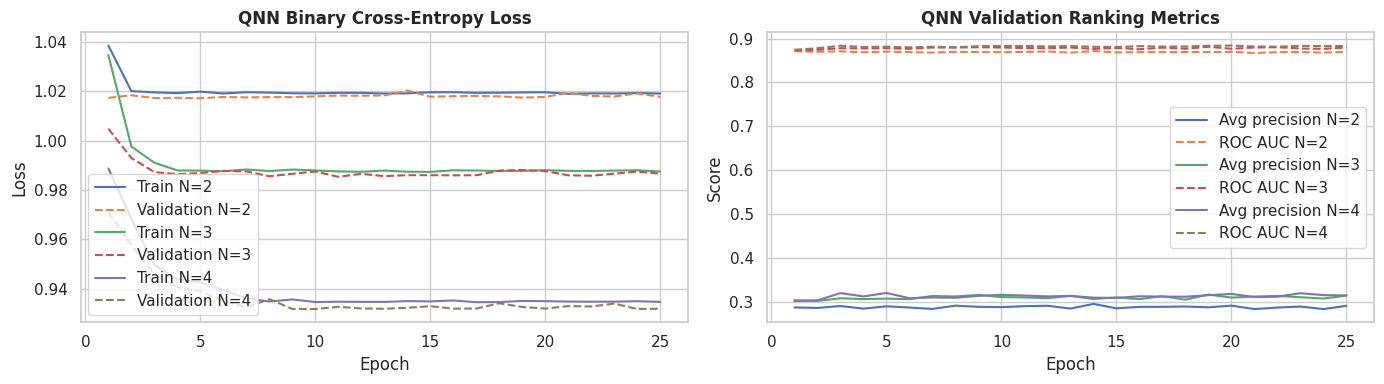

,quantum_parameters,val_loss,threshold,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,val_avg_precision,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_avg_precision
reuploads,,,,,,,,,,,,,,,
2,30,1.0177,0.5494,0.7793,0.2971,0.9278,0.4500,0.8697,0.2908,0.7755,0.2941,0.9329,0.4472,0.8689,0.2943
3,45,0.9866,0.5614,0.7885,0.3032,0.9040,0.4541,0.8795,0.3141,0.7865,0.3023,0.9133,0.4543,0.8712,0.2950
4,60,0.9319,0.6003,0.7975,0.3118,0.8955,0.4626,0.8830,0.3147,0.7920,0.3058,0.8955,0.4559,0.8743,0.2949


In [16]:
all_history_df = pd.concat([result["history"] for result in experiment_results], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for reuploads, group in all_history_df.groupby("reuploads"):
    axes[0].plot(group["epoch"], group["train_loss"], label=f"Train N={reuploads}")
    axes[0].plot(group["epoch"], group["val_loss"], linestyle="--", label=f"Validation N={reuploads}")
    axes[1].plot(group["epoch"], group["val_avg_precision"], label=f"Avg precision N={reuploads}")
    axes[1].plot(group["epoch"], group["val_roc_auc"], linestyle="--", label=f"ROC AUC N={reuploads}")

axes[0].set_title("QNN Binary Cross-Entropy Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].set_title("QNN Validation Ranking Metrics", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()

comparison_df.round(4)

## 14. Validation Threshold

At probability threshold `0.50`, positive Pauli-Z readout predicts hazardous. The tuned threshold below maximizes validation F1.

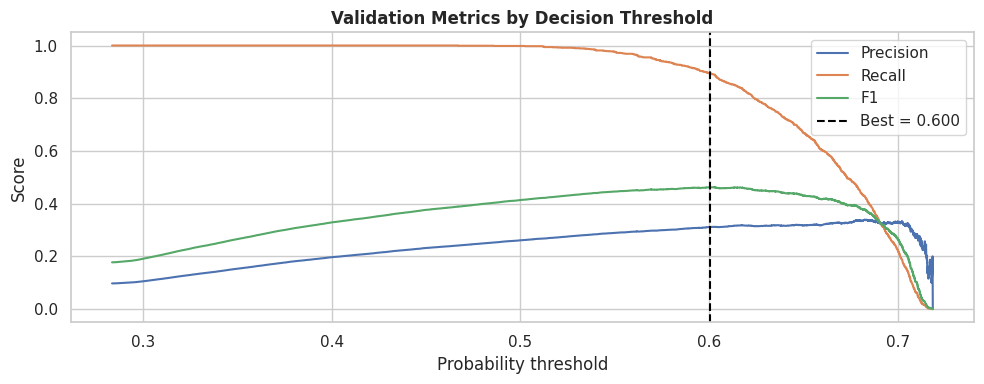

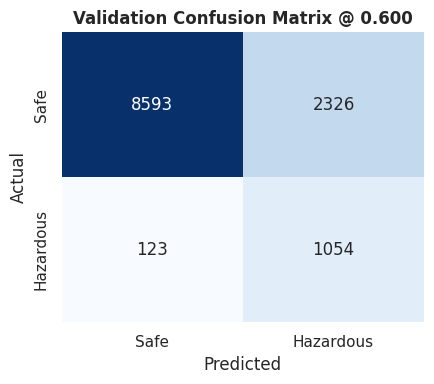

,accuracy,precision,recall,f1,roc_auc,avg_precision
threshold 0.50,0.7249,0.2611,0.9983,0.4139,0.8830,0.3147
threshold 0.600,0.7975,0.3118,0.8955,0.4626,0.8830,0.3147


In [17]:
threshold_curve = best_result["threshold_curve"]
baseline = evaluate(model, X_val_qnn, y_val_qnn, threshold=0.50)
tuned = best_result["validation"]

validation_metrics_df = pd.DataFrame(
    [baseline["metrics"], tuned["metrics"]],
    index=["threshold 0.50", f"threshold {best_threshold:.3f}"],
).round(4)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(threshold_curve["threshold"], threshold_curve["precision"], label="Precision")
ax.plot(threshold_curve["threshold"], threshold_curve["recall"], label="Recall")
ax.plot(threshold_curve["threshold"], threshold_curve["f1"], label="F1")
ax.axvline(best_threshold, color="black", linestyle="--", label=f"Best = {best_threshold:.3f}")
ax.set_title("Validation Metrics by Decision Threshold", fontweight="bold")
ax.set_xlabel("Probability threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

plot_confusion_matrix(y_val_qnn, tuned["y_pred"], f"Validation Confusion Matrix @ {best_threshold:.3f}")

validation_metrics_df

## 15. Held-Out Test Evaluation

Each requested depth is evaluated on the test split with its own validation-tuned threshold for comparison. The selected final model is still chosen by validation F1, not by test performance.

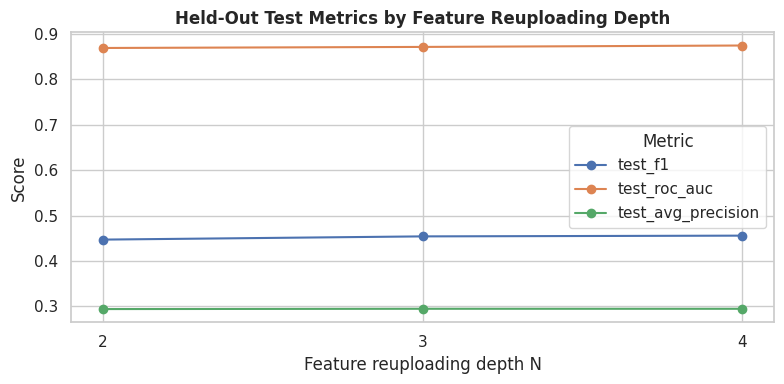

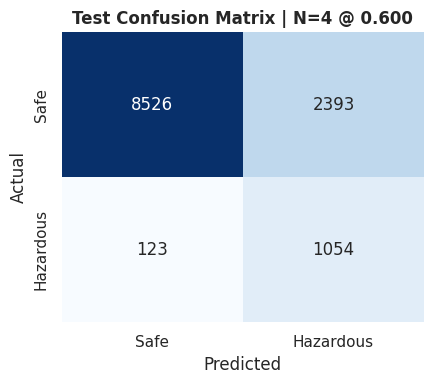

Selected feature reuploading depth N=4.


,quantum_parameters,val_loss,threshold,val_f1,val_roc_auc,val_avg_precision,test_f1,test_roc_auc,test_avg_precision
reuploads,,,,,,,,,
2,30,1.0177,0.5494,0.4500,0.8697,0.2908,0.4472,0.8689,0.2943
3,45,0.9866,0.5614,0.4541,0.8795,0.3141,0.4543,0.8712,0.2950
4,60,0.9319,0.6003,0.4626,0.8830,0.3147,0.4559,0.8743,0.2949


In [18]:
final_metrics_df = pd.DataFrame([result["summary"] for result in experiment_results]).set_index("reuploads")

metric_columns = [
    "quantum_parameters",
    "val_loss",
    "threshold",
    "val_f1",
    "val_roc_auc",
    "val_avg_precision",
    "test_f1",
    "test_roc_auc",
    "test_avg_precision",
]

fig, ax = plt.subplots(figsize=(8, 4))
final_metrics_df[["test_f1", "test_roc_auc", "test_avg_precision"]].plot(marker="o", ax=ax)
ax.set_title("Held-Out Test Metrics by Feature Reuploading Depth", fontweight="bold")
ax.set_xlabel("Feature reuploading depth N")
ax.set_ylabel("Score")
ax.set_xticks(final_metrics_df.index)
ax.legend(title="Metric")
plt.tight_layout()
plt.show()

plot_confusion_matrix(
    y_te_qnn,
    best_result["test"]["y_pred"],
    f"Test Confusion Matrix | N={best_result['reuploads']} @ {best_threshold:.3f}",
)

print(f"Selected feature reuploading depth N={best_result['reuploads']}.")
final_metrics_df[metric_columns].round(4)

## 16. Interpretation

The notebook now uses a compact Torch-centered quantum-only pipeline:

- The data pipeline uses sklearn for the stratified train/validation/test split, standardization, optional PCA, and min-max angle scaling. In the saved configuration `USE_PCA = False`, so all 5 standardized engineered features are angle-scaled and passed to a 5-qubit circuit.
- The QNode uses `default.qubit` with `interface="torch"` and `diff_method="backprop"`, so the circuit is connected directly to Torch autograd.
- `FEATURE_REUPLOADS = [2, 3, 4]` trains and compares the requested feature-reuploading depths.
- The classifier has no classical neural-network layers.
- The only trainable parameters are the quantum ansatz angles `theta`.
- The Pauli-Z expectation is used as the binary logit.
- Validation data selects each decision threshold and the final depth; the held-out test split is reported afterward for the depth comparison and selected model.

The QNN tensors are moved to `torch_device`, which is set to CUDA in this notebook. The saved run therefore simulates the 5-qubit `default.qubit` circuit with Torch tensors on the CUDA device while using Torch autograd throughout the model.